# Principles of Data Science | Homework Assignment 3 (HA3) :  Societal Mood

For this assignment, we will reconsider the data set that is extracted from social media. As previously introduced, it covers a collection of users on social media that were retrieved based on posts that referenced a list of keywords related to the COVID-19 pandemic. Among all messages acquired with these keywords, those users were extacted that indicated their location was a city in the Netherlands. Specifically, we take a look at the accounts that specified "Maastricht" as their location.

First we load the necessary python packages

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

tab10 = plt.get_cmap("tab10").colors

### Exercise 1. (*1pt*)
Load the data set as provided in the files `users_HA3.tsv` and `tweets_HA3.tsv` into the variables `users` and `tweets`, respectively. Make sure that you convert the times at which the tweets are created from strings into a usable format.

#### Solution

In [14]:
users = pd.read_csv("users_HA3.tsv", sep="\t")
users.head()

,Unnamed: 0,gender,gender.1,twitter,twitter.1
0,NaN,male,female,followers,friends
1,user_id,NaN,NaN,NaN,NaN
2,043u0001,0.9428,0.0572,733,894
3,043u0003,0.9649,0.0351,92,647
4,043u0006,0.7454,0.2546,276,278


In [15]:
tweet = pd.read_csv("tweets_HA3.tsv", sep="\t", index_col="user_id")
tweet.head()

,tweet_id,created_at,ANEW_Arousal,ANEW_Dominance,ANEW_Valence
user_id,,,,,
043u0001,043t0000000,2020-04-23 12:45:58+00:00,4.171667,4.226667,4.236667
043u0001,043t0000001,2020-04-23 11:28:08+00:00,3.533333,3.986667,3.940000
043u0001,043t0000002,2020-04-23 11:19:08+00:00,NaN,NaN,NaN
043u0001,043t0000003,2020-04-22 22:31:24+00:00,NaN,NaN,NaN
043u0001,043t0000004,2020-04-22 15:06:45+00:00,3.300000,4.030000,4.310000


In [16]:
tweet["created_at"] = pd.to_datetime(tweet["created_at"])
tweet["date"] = tweet["created_at"].dt.date
tweety = tweet[[c for c in tweet.columns if "ANEW" in c]].isna().sum(axis=1) == 0
tweets = tweet[tweety]
tweets

,tweet_id,created_at,ANEW_Arousal,ANEW_Dominance,ANEW_Valence,date
user_id,,,,,,
043u0001,043t0000000,2020-04-23 12:45:58+00:00,4.171667,4.226667,4.236667,2020-04-23
043u0001,043t0000001,2020-04-23 11:28:08+00:00,3.533333,3.986667,3.940000,2020-04-23
043u0001,043t0000004,2020-04-22 15:06:45+00:00,3.300000,4.030000,4.310000,2020-04-22
043u0001,043t0000005,2020-04-21 15:48:09+00:00,3.704000,4.198000,4.162000,2020-04-21
043u0001,043t0000006,2020-04-21 14:04:33+00:00,3.596667,3.843333,3.316667,2020-04-21
...,...,...,...,...,...,...
043u0088,043t0092882,2020-04-27 09:31:44+00:00,3.880000,4.410000,4.380000,2020-04-27
043u0088,043t0092883,2020-04-25 11:02:30+00:00,4.920000,4.746667,4.970000,2020-04-25
043u0088,043t0092884,2020-04-25 10:42:52+00:00,3.360000,3.945000,3.850000,2020-04-25


## Differences between male and female accounts
When processing the accounts that were collected in the data gathering phase, the researchers also analyzed the profile pages of the accounts using a gender classifier. The file `users_HA3.tsv` contains the outcomes of this classification. For each account, the classifier outputs a probability that an account would be classified with either label.

The researchers want to analyze the difference in expressed mood between male and female accounts. They decide that they will use a cut-off at a probability of `0.8` as an inclusion criterium. So if an account scores more than `0.8` on either male or female probability, it is included in that group for further analysis.

### Exercise 2. (*3pt*)
Visualize the ANEW Valence distribution of all tweets from the accounts that are classified as male and female.

#### Solution

In [17]:
# (I used an AI-Tool a little bit for the visualization part, for the code to delete the first two columns and for the code to change type of
# the variables from str to float in this exercise.)

newusers = users.rename(columns={'Unnamed: 0': 'user_id'})
newusers.set_index("user_id", inplace=True)

newusers1 = newusers.iloc[2:]

newusers1["gender"] = newusers1["gender"].astype(float)
newusers1["gender.1"] = newusers1["gender.1"].astype(float)

newusers["sex"] = None
newusers1_male = newusers1.loc[newusers1['gender'] > 0.8, "sex"] = "m"

newusers1_female = newusers1.loc[newusers1['gender.1'] > 0.8, "sex"]= "f"

newusers1

,gender,gender.1,twitter,twitter.1,sex
user_id,,,,,
043u0001,0.9428,0.0572,733,894,m
043u0003,0.9649,0.0351,92,647,m
043u0006,0.7454,0.2546,276,278,NaN
043u0015,0.0009,0.9991,8576,5726,f
043u0016,0.0073,0.9927,42,382,f
043u0017,0.9971,0.0029,699,1130,m
043u0018,1.0000,0.0000,737,666,m
043u0019,0.9953,0.0047,1344,1165,m
043u0021,0.9998,0.0002,732,756,m


In [18]:
a = tweets.groupby('user_id')['ANEW_Valence'].mean()
students = pd.concat([a, newusers1], axis=1)
students

,ANEW_Valence,gender,gender.1,twitter,twitter.1,sex
user_id,,,,,,
043u0001,4.201714,0.9428,0.0572,733,894,m
043u0003,4.584654,0.9649,0.0351,92,647,m
043u0006,4.390312,0.7454,0.2546,276,278,NaN
043u0015,4.534500,0.0009,0.9991,8576,5726,f
043u0016,4.004566,0.0073,0.9927,42,382,f
043u0017,4.132368,0.9971,0.0029,699,1130,m
043u0018,4.227594,1.0000,0.0000,737,666,m
043u0019,4.232361,0.9953,0.0047,1344,1165,m
043u0021,4.526302,0.9998,0.0002,732,756,m


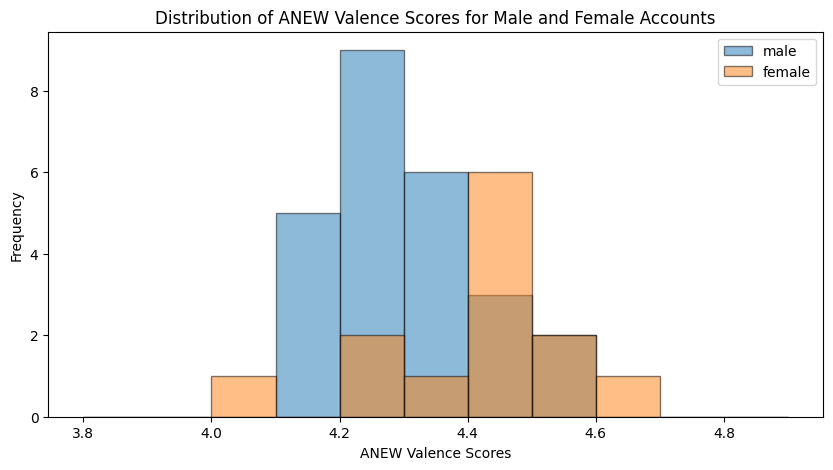

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(students[students['sex'] == 'm']['ANEW_Valence'], bins=np.arange(3.8, 4.9, 0.1), alpha=0.5, color='tab:blue', edgecolor="k", label='male')
plt.hist(students[students['sex'] == 'f']['ANEW_Valence'], bins=np.arange(3.8, 4.9, 0.1), alpha=0.5, color='tab:orange', edgecolor="k", label='female')
plt.legend(loc='upper right')
plt.xlabel('ANEW Valence Scores')
plt.ylabel('Frequency')
plt.title('Distribution of ANEW Valence Scores for Male and Female Accounts')
plt.show()

Based on the visual comparison above, the researchers want to determine whether the male and female averages align. Therefore, they run a one sided statistical test.

### Exercise 3. (*2pt*)
Denote the null-hypothesis and alternative hypothesis for this test.

#### Solution

- $H_0$ (null-hypothesis): ***the average of male is 4.2 and the average of female is 4.4***.
- $H_a$ (alternative hypothesis): ***the average of male is higher than 4.2 and the average of female is higher than 4.4***.

Suppose that we may assume that the average ANEW Valence score for female accounts follows a normal distribution. We determine the mean and standard deviation of the distribution directly from the data.

### Exercise 4. (*2pt*)
Determine the value of the test-statictic and the $P$-value.

#### Solution

In [20]:
# I used an AI-Tool as a help to create the code.

#Here by this 2 lines.
filtered_data = students.loc[students['sex'] == 'f']
female_array = filtered_data['ANEW_Valence'].values

n = 13

#Here by this 3 lines.
observed = female_array.sum()/13
std_dev = np.std(female_array)
sem = std_dev/ np.sqrt(n)

expected = 4.4

test_statistic = (observed - expected) / sem
test_statistic

0.16157880822873996

In [21]:
p_value = norm.cdf(test_statistic)
p_value

0.5641812267084234

## Response to COVID-19
To assess each accounts reaction to the start of the COVID-19 pandemic, we will investigate the difference the average ANEW Valence in the month before the first COVID-19 case was observed in the Netherlands (i.e., December 2019) and a month after (i.e., March 2020).

### Exercise 5. (*2pt*)
Which accounts have the biggest and lowest difference in average ANEW Valence across these two months?

#### Solution

In [22]:
# I used an AI-Tool for this part: ".astype(str).str[:7].isin" of line 1 of the code.

filtered_data_4months = tweets[tweets['date'].astype(str).str[:7].isin(['2019-12', '2020-01', '2020-02', '2020-03'])]
filtered_data_4months

,tweet_id,created_at,ANEW_Arousal,ANEW_Dominance,ANEW_Valence,date
user_id,,,,,,
043u0001,043t0000065,2020-03-30 10:59:10+00:00,3.740000,4.160000,3.517500,2020-03-30
043u0001,043t0000066,2020-03-29 16:43:51+00:00,4.446667,4.283333,3.766667,2020-03-29
043u0001,043t0000067,2020-03-29 14:24:27+00:00,4.613333,3.960000,4.923333,2020-03-29
043u0001,043t0000069,2020-03-28 22:21:14+00:00,3.993333,4.298333,4.323333,2020-03-28
043u0001,043t0000071,2020-03-28 12:50:10+00:00,3.720000,3.870000,4.015000,2020-03-28
...,...,...,...,...,...,...
043u0088,043t0092465,2019-12-05 22:08:44+00:00,4.053333,4.753333,5.136667,2019-12-05
043u0088,043t0092466,2019-12-05 16:34:44+00:00,3.630000,3.140000,2.670000,2019-12-05
043u0088,043t0092467,2019-12-03 22:23:14+00:00,4.646000,4.722000,3.746000,2019-12-03


In [23]:
a_anew = filtered_data_4months.groupby('user_id')['ANEW_Valence'].mean()
big_na = a_anew .idxmax(axis=0)
big_nu = a_anew .max(axis=0).max() 
print ("The account", big_na, "has the biggest difference in average ANEW Valence with", big_nu, " in these two months.")

The account 043u0003 has the biggest difference in average ANEW Valence with 4.72  in these two months.


In [24]:
lowest_na = a_anew.idxmin(axis=0) 
lowest_nu = a_anew.min(axis=0).min() 
print ("The account", lowest_na, "has the lowest difference in average ANEW Valence with", lowest_nu, " in these two months.")

The account 043u0058 has the lowest difference in average ANEW Valence with 3.4966666666666666  in these two months.
